# Podyum & Kazanan Tahmin Modeli — Lojistik Regresyon

**Amaç:** Yarış öncesi bilinen bilgiyle **her yarışta kimin podyuma çıkacağını ve kimin kazanacağını tahmin etmek.**
Bu bölüm *sonucu ne belirliyor* sorusunu değil, doğrudan **tahmin** performansını hedefliyor.

**Problem tipi:** İkili sınıflandırma (podyum = 1 / değil = 0) → **lojistik regresyon.**

**Bu notebook'ta üç şey yapıyoruz:**
1. **Zengin özellik seti** — grid + form + sıralama turu + **hava** + **pist**
2. **İki bölme karşılaştırması** — zamana göre bölme vs rastgele bölme (hangisi dürüst?)
3. **Kademeli deney** — özellik ekledikçe tahmin ne kadar iyileşiyor?

**Kapsam:** 2003–2024, yarışa başlamış kayıtlar.

**Sızıntı kuralı:** Yarış *sonrası* alanlar (bitiş pozisyonu, puan, DNF, takım arkadaşı bitiş farkı) modele **girmez** — sadece yarış başlamadan bilinen bilgi.

## 1 · Veri

`mart_race_results`'tan yarış-öncesi özellikleri ve hedefi (`is_podium`) çekiyoruz.
Hava (`precip_total_mm`, `temperature_c`, `weather_condition`) ve pist (`circuit_name`) de dahil.

In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import numpy as np

PROJECT_ID = "f1-analytics-505812"
client = bigquery.Client(project=PROJECT_ID)

query = """
SELECT
    season_year, round_number, race_name, driver_name,
    grid_position, is_pole,
    team_form_5_pos, driver_form_5_pos, form_race_count,
    quali_gap_teammate_ms,
    precip_total_mm, temperature_c, weather_condition,
    circuit_name,
    is_podium, is_win
FROM `f1_analytics.mart_race_results`
WHERE season_year BETWEEN 2003 AND 2024
  AND did_start
"""

ham = client.query(query, location="EU").to_dataframe()

# Form penceresi dolmayan ve cekirdek ozelligi eksik kayitlari cikar
d = ham[ham["form_race_count"] >= 5].copy()
d = d.dropna(subset=["grid_position", "team_form_5_pos", "driver_form_5_pos"])
d = d.reset_index(drop=True)

print(f"Kayit sayisi: {len(d)}")
print(f"Podyum orani: %{d['is_podium'].mean()*100:.1f}")

Kayit sayisi: 6328
Podyum orani: %14.8


## 2 · Özellikler ve hazırlık

**Sayısal:** grid, takım formu, sürücü formu, form yarış sayısı, sıralama turu farkı, yağış, sıcaklık
**İkili:** pole mu (grid = 1)
**Kategorik (one-hot):** pist adı, hava durumu kategorisi

**Eksik veri:**
- `quali_gap_teammate_ms` bazen boş (takım arkadaşı yoksa) → 0 doldurup ayrı bir "eksik" bayrağı ekliyoruz
- `precip_total_mm` boşsa 0 (yağmursuz), `temperature_c` boşsa medyan

One-hot kodlama, pist ve hava kategorisini modelin okuyabileceği 0/1 sütunlara çeviriyor.

In [ ]:
# metadata (kimlik) sutunlari ozellik DEGIL — ayri tutuyoruz
META = ["season_year", "round_number", "race_name", "driver_name", "is_podium", "is_win"]
X = d.drop(columns=META).copy()
X["is_pole"] = X["is_pole"].astype(int)

# eksik veri doldurma (deterministik -> sizinti yok)
X["quali_gap_missing"] = X["quali_gap_teammate_ms"].isna().astype(int)
X["quali_gap_teammate_ms"] = X["quali_gap_teammate_ms"].fillna(0.0)
X["precip_total_mm"] = X["precip_total_mm"].fillna(0.0)
X["temperature_c"] = X["temperature_c"].fillna(X["temperature_c"].median())

# kategorikleri one-hot
X = pd.get_dummies(X, columns=["circuit_name", "weather_condition"],
                   drop_first=True, dtype=int)

y = d["is_podium"].astype(int).values

# ozellik gruplari
SUREKLI = ["grid_position", "team_form_5_pos", "driver_form_5_pos", "form_race_count",
           "quali_gap_teammate_ms", "precip_total_mm", "temperature_c"]
pist_kol = [c for c in X.columns if c.startswith("circuit_name_")]
hava_kol = [c for c in X.columns if c.startswith("weather_condition_")]

print(f"Toplam ozellik sutunu: {len(SUREKLI) + 2 + len(pist_kol) + len(hava_kol)}")
print(f"  surekli: {len(SUREKLI)} | pist(one-hot): {len(pist_kol)} | hava-kat: {len(hava_kol)}")

Toplam ozellik sutunu: 47
  surekli: 7 | pist(one-hot): 36 | hava-kat: 2


## 3 · Ortak yardımcı fonksiyonlar

`egit()` bir özellik listesi + eğitim/test maskesi alıyor; ölçeklemeyi **yalnızca eğitim setinde** öğrenip teste uyguluyor (sızıntı yok), modeli kuruyor, test olasılıklarını döndürüyor.
`skorla()` accuracy / precision / recall / F1 yazdırıyor.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             accuracy_score, confusion_matrix)


def egit(feat, eg, te, esik=0.5):
    sk = [c for c in feat if c in SUREKLI]          # sadece surekli olanlari olcekle
    olcek = StandardScaler().fit(X.loc[eg, sk])
    Xtr = X.loc[eg, feat].copy()
    Xte = X.loc[te, feat].copy()
    Xtr[sk] = olcek.transform(Xtr[sk])
    Xte[sk] = olcek.transform(Xte[sk])

    m = LogisticRegression(max_iter=2000)
    m.fit(Xtr, y[eg.values])
    olasilik = m.predict_proba(Xte)[:, 1]
    tahmin = (olasilik >= esik).astype(int)
    return m, olasilik, tahmin


def skorla(ad, y_true, tahmin):
    print(f"{ad:28s} Acc %{accuracy_score(y_true, tahmin)*100:4.1f} | "
          f"P %{precision_score(y_true, tahmin, zero_division=0)*100:4.1f} | "
          f"R %{recall_score(y_true, tahmin, zero_division=0)*100:4.1f} | "
          f"F1 %{f1_score(y_true, tahmin, zero_division=0)*100:4.1f}")


# tam ozellik seti (grid + form + quali + hava + pist)
TUM = (SUREKLI + ["is_pole", "quali_gap_missing"] + pist_kol + hava_kol)
print(f"Tam ozellik seti: {len(TUM)} sutun")

Tam ozellik seti: 47 sutun


## 4 · İki bölme: zamana göre vs rastgele

Hoca sordu: *"Yıllara göre böldük ama rastgele bölseydik nasıl olurdu?"*

Aynı zengin modeli **iki farklı bölmeyle** kurup test skorlarını yan yana koyuyoruz:

- **Zaman bölmesi:** eğitim 2003–2016, test 2017–2024 → gerçekçi (geçmişe bakıp geleceği tahmin)
- **Rastgele bölme:** kayıtlar karıştırılıp %60 eğitim / %40 test → yıl karışıyor

Aynı test oranı (%40) kullanıyoruz ki karşılaştırma adil olsun.

In [ ]:
from sklearn.model_selection import train_test_split

# --- Zaman bolmesi ---
eg_zaman = d["season_year"] <= 2016
te_zaman = d["season_year"] >= 2017

# --- Rastgele bolme (ayni %40 test orani, stratify: podyum orani korunur) ---
idx = np.arange(len(d))
_, te_idx = train_test_split(idx, test_size=0.40, random_state=42, stratify=y)
te_random = pd.Series(False, index=d.index)
te_random.iloc[te_idx] = True
eg_random = ~te_random


def bolme_raporu(baslik, eg, te):
    print(f"\n=== {baslik} ===")
    print(f"Egitim {int(eg.sum())} | Test {int(te.sum())} | "
          f"test podyum orani %{y[te.values].mean()*100:.1f}")
    _, _, tahmin = egit(TUM, eg, te, esik=0.5)
    yt = y[te.values]
    # baseline: grid <= 3
    base = (d.loc[te, "grid_position"] <= 3).astype(int).values
    skorla("Baseline (grid<=3)", yt, base)
    skorla("Model (zengin, esik 0.5)", yt, tahmin)


bolme_raporu("ZAMAN BOLMESI (2003-16 / 2017-24)", eg_zaman, te_zaman)
bolme_raporu("RASTGELE BOLME (%60/%40)",          eg_random, te_random)


=== ZAMAN BOLMESI (2003-16 / 2017-24) ===
Egitim 3825 | Test 2503 | test podyum orani %15.4
Baseline (grid<=3)           Acc %89.9 | P %67.4 | R %66.8 | F1 %67.1
Model (zengin, esik 0.5)     Acc %89.4 | P %69.0 | R %57.0 | F1 %62.4

=== RASTGELE BOLME (%60/%40) ===
Egitim 3796 | Test 2532 | test podyum orani %14.8
Baseline (grid<=3)           Acc %89.7 | P %65.0 | R %66.2 | F1 %65.6
Model (zengin, esik 0.5)     Acc %89.5 | P %69.2 | R %53.2 | F1 %60.2


### Yorum: rastgele bölme neden yanıltıcı?

Bu veri setinde rastgele bölme F1'i **düşürdü** (%60,2 vs %62,4). Ama bu, rastgele
bölmenin "daha dürüst" olduğu anlamına gelmiyor — iki bölme farklı test kümelerine
bakıyor, skorlar doğrudan karşılaştırılabilir değil. Baseline bile iki bölmede
farklı çıkıyor (%67,1 vs %65,6).

Asıl sorun metodolojik: rastgele böldüğümüzde aynı sezonun yarışları hem eğitimde
hem testte oluyor. Model, 2023'te Red Bull'un baskın olduğunu eğitimde görüp aynı
sezonun test yarışlarında bunu "ezberden" biliyor. Geleceği tahmin etmiyor, gördüğü
dönemi hatırlıyor.

Gerçek kullanımda elimizde gelecek sezonun verisi olmayacak. O yüzden **zaman
bölmesiyle devam ediyoruz** — skoru yükselttiği için değil, soruyu doğru sorduğu
için.

## 5 · Kademeli özellik deneyi

Zengin özellik seti gerçekten fark yaratıyor mu? Zaman bölmesinde özellikleri kademeli ekliyoruz:

1. **Temel:** grid + form + pole
2. **+ Sıralama turu:** takım arkadaşına göre quali farkı
3. **+ Hava & Pist:** yağış, sıcaklık, hava kategorisi, pist (one-hot)

Her adımda F1 nasıl değişiyor görüyoruz.

In [ ]:
E1 = SUREKLI[:4] + ["is_pole"]                              # grid + 3 form + pole
E2 = E1 + ["quali_gap_teammate_ms", "quali_gap_missing"]    # + quali
E3 = TUM                                                    # + hava + pist

yt = y[te_zaman.values]
base = (d.loc[te_zaman, "grid_position"] <= 3).astype(int).values
skorla("Baseline (grid<=3)", yt, base)
for ad, feat in [("1) Temel (grid+form)", E1),
                 ("2) + Siralama turu",   E2),
                 ("3) + Hava & Pist",     E3)]:
    _, _, tahmin = egit(feat, eg_zaman, te_zaman, esik=0.5)
    skorla(ad, yt, tahmin)

Baseline (grid<=3)           Acc %89.9 | P %67.4 | R %66.8 | F1 %67.1
1) Temel (grid+form)         Acc %89.5 | P %69.2 | R %57.0 | F1 %62.5
2) + Siralama turu           Acc %89.5 | P %69.4 | R %57.0 | F1 %62.6
3) + Hava & Pist             Acc %89.4 | P %69.0 | R %57.0 | F1 %62.4


### Yorum: zengin özellikler işe yaramadı

Beklentimiz özellik ekledikçe F1'in yükselmesiydi. Olmadı:

| Özellik seti | F1 |
|---|---|
| 1) Temel (grid + form + pole) | %62,5 |
| 2) + Sıralama turu farkı | %62,6 |
| 3) + Hava & pist (47 sütun) | %62,4 |

Sıralama turu 0,1 puan ekliyor, hava ve pist ise **geri alıyor.** Üçü de baseline'ın
(%67,1) altında.

Bu bir başarısızlık değil, bulgu. İki sebebi var:

**Sıralama turu neden katkı yapmıyor?** Çünkü `grid_position` zaten sıralama turunun
sonucu. Takım arkadaşına göre fark, grid'in üstüne yeni bilgi taşımıyor.

**Pist neden katkı yapmıyor?** Pist, sahanın genel sırasını karıştırıyor ama
podyumdaki üç aracı karıştırmıyor. Öngörülebilir pistlerde ilk üçten başlayanların
podyum oranı %63,0, riskli pistlerde %59,9 — 3 puanlık tavan, 36 one-hot sütunun
getirdiği gürültünün altında kalıyor.

Sonuç: **grid ve form dışındaki her şey bu problemde gürültü.** Modelin gerçek
kazancı özellik eklemekten değil, bir sonraki bölümdeki eşik ayarından geliyor.

## 6 · Eşik ayarı (zaman bölmesi, tam model)

Podyum nadir (%15) olduğu için varsayılan 0.5 eşiği fazla temkinli. Eşiği düşürünce model daha çok podyum yakalar (recall ↑) ama yanlış alarm artar (precision ↓). En iyi F1'i veren eşiği arıyoruz.

In [ ]:
_, olasilik, _ = egit(TUM, eg_zaman, te_zaman, esik=0.5)
yt = y[te_zaman.values]

print(f"{'Esik':>6} {'Precision':>10} {'Recall':>8} {'F1':>7} {'Tahmin':>8}")
for esik in [0.50, 0.45, 0.40, 0.35, 0.30]:
    t = (olasilik >= esik).astype(int)
    print(f"{esik:6.2f} {precision_score(yt,t,zero_division=0)*100:9.1f} "
          f"{recall_score(yt,t,zero_division=0)*100:8.1f} "
          f"{f1_score(yt,t,zero_division=0)*100:7.1f} {t.sum():8d}")

base = (d.loc[te_zaman, 'grid_position'] <= 3).astype(int).values
print(f"\nBaseline F1: %{f1_score(yt, base)*100:.1f}")
print(f"Test podyum sayisi: {yt.sum()}")

  Esik  Precision   Recall      F1   Tahmin
  0.50      69.0     57.0    62.4      319
  0.45      67.2     63.2    65.2      363
  0.40      64.9     69.9    67.3      416
  0.35      62.3     77.5    69.1      480
  0.30      57.8     80.6    67.3      538

Baseline F1: %67.1
Test podyum sayisi: 386


## 7 · Seçilen eşikte sonuç ve karışıklık matrisi

En iyi F1'i veren eşiği seçip (yukarıdaki tablodan) modelin son halini raporluyoruz.

Model (esik 0.4)             Acc %89.5 | P %64.9 | R %69.9 | F1 %67.3
Baseline (grid<=3)           Acc %89.9 | P %67.4 | R %66.8 | F1 %67.1

Karışıklık matrisi · model (eşik 0.4)
  Dogru elenen (TN)     : 1971
  Yanlis alarm (FP)     : 146
  Kacirilan podyum (FN) : 116
  Yakalanan podyum (TP) : 270


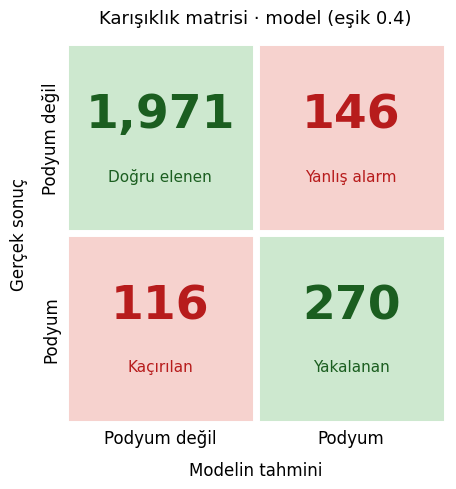

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

SECILEN_ESIK = 0.40      # yukaridaki tablodan en iyi F1'e gore ayarla

_, olasilik, _ = egit(TUM, eg_zaman, te_zaman)
tahmin = (olasilik >= SECILEN_ESIK).astype(int)
yt = y[te_zaman.values]

skorla(f"Model (esik {SECILEN_ESIK})", yt, tahmin)
skorla("Baseline (grid<=3)", yt, (d.loc[te_zaman,'grid_position']<=3).astype(int).values)


def kare_matris(y_true, tahmin, baslik, dosya):
    cm = confusion_matrix(y_true, tahmin)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{baslik}")
    print(f"  Dogru elenen (TN)     : {tn}")
    print(f"  Yanlis alarm (FP)     : {fp}")
    print(f"  Kacirilan podyum (FN) : {fn}")
    print(f"  Yakalanan podyum (TP) : {tp}")

    dogru = np.array([[1, 0], [0, 1]])
    cmap = ListedColormap(["#F6D2CE", "#CDE8CF"])
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(dogru, cmap=cmap, vmin=0, vmax=1)
    etiket = ["Podyum değil", "Podyum"]
    ax.set_xticks([0, 1]); ax.set_xticklabels(etiket, fontsize=12)
    ax.set_yticks([0, 1]); ax.set_yticklabels(etiket, fontsize=12, rotation=90, va="center")
    ax.set_xlabel("Modelin tahmini", fontsize=12, labelpad=10)
    ax.set_ylabel("Gerçek sonuç", fontsize=12, labelpad=10)
    ax.set_title(baslik, fontsize=13, pad=14)
    acik = [["Doğru elenen", "Yanlış alarm"], ["Kaçırılan", "Yakalanan"]]
    for i in range(2):
        for j in range(2):
            koyu = "#1B5E20" if dogru[i, j] else "#B71C1C"
            ax.text(j, i - 0.12, f"{cm[i, j]:,}", ha="center", va="center",
                    fontsize=34, fontweight="bold", color=koyu)
            ax.text(j, i + 0.20, acik[i][j], ha="center", va="center", fontsize=11, color=koyu)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=5)
    ax.tick_params(which="minor", length=0); ax.tick_params(length=0)
    plt.tight_layout(); plt.savefig(dosya, dpi=200, facecolor="white"); plt.show()


kare_matris(yt, tahmin, f"Karışıklık matrisi · model (eşik {SECILEN_ESIK})",
            "tahmin_karisiklik.png")

## 8 · Yarış bazında tahmin: kazanan ve podyum

Asıl hedef bu: model her yarışta **kimin kazanacağını ve podyuma çıkacağını** tahmin edebiliyor mu?

Model her sürücüye bir podyum olasılığı veriyor. Bir yarış için:
- **Tahmini kazanan** = o yarışta **en yüksek** olasılığa sahip sürücü (ilk 1)
- **Tahmini podyum** = en yüksek **ilk 3** sürücü

Bunu tüm test yarışlarında ölçüp **baseline (sadece grid sırası)** ile karşılaştırıyoruz.

In [ ]:
_, olasilik_test, _ = egit(TUM, eg_zaman, te_zaman)

# tahminleri kimlik bilgisiyle birlestir
T = d.loc[te_zaman, ["season_year", "round_number", "race_name",
                     "driver_name", "grid_position", "is_podium", "is_win"]].copy()
T["olasilik"] = olasilik_test


def yaris_metrik(g):
    m1 = g.nlargest(1, "olasilik")            # modelin tahmini kazanani
    m3 = g.nlargest(3, "olasilik")            # modelin tahmini podyumu
    b1 = g.nsmallest(1, "grid_position")      # baseline: pole (grid 1)
    b3 = g.nsmallest(3, "grid_position")      # baseline: grid ilk 3
    return pd.Series({
        "model_kazanan":    int(m1["is_win"].sum() >= 1),
        "model_podyum":     int(m3["is_podium"].sum()),
        "baseline_kazanan": int(b1["is_win"].sum() >= 1),
        "baseline_podyum":  int(b3["is_podium"].sum()),
    })


sonuc = T.groupby(["season_year", "round_number"]).apply(yaris_metrik)
n = len(sonuc)
print(f"Test yaris sayisi: {n}\n")
print(f"{'':10s} {'Kazanan dogru':>16s} {'Podyum isabet (3 uzerinden)':>30s}")
print(f"{'Model':10s} %{sonuc['model_kazanan'].mean()*100:14.1f} "
      f"{sonuc['model_podyum'].mean():17.2f}/3  (%{sonuc['model_podyum'].mean()/3*100:.1f})")
print(f"{'Baseline':10s} %{sonuc['baseline_kazanan'].mean()*100:14.1f} "
      f"{sonuc['baseline_podyum'].mean():17.2f}/3  (%{sonuc['baseline_podyum'].mean()/3*100:.1f})")

Test yaris sayisi: 129

              Kazanan dogru    Podyum isabet (3 uzerinden)
Model      %          50.4              2.01/3  (%66.9)
Baseline   %          50.4              2.02/3  (%67.2)


/tmp/ipykernel_4703/3762105525.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sonuc = T.groupby(["season_year", "round_number"]).apply(yaris_metrik)


### Yarış örnekleri

Bir test yarışını seçip modelin sürücüleri podyum olasılığına göre sıraladığını ve gerçek sonucla nasıl örtüştüğünü gösteriyoruz. Aşağıda **iki yarış** var; `yaris_goster(sezon, tur)` ile istediğin başka yarışı da deneyebilirsin (örn. `yaris_goster(2023, 7)`).

In [ ]:
def yaris_goster(sezon, tur):
    g = T[(T["season_year"] == sezon) & (T["round_number"] == tur)].copy()
    if g.empty:
        print(f"{sezon} tur {tur}: bu yaris test setinde yok.")
        return
    g = g.sort_values("olasilik", ascending=False).reset_index(drop=True)
    g["tahmini_podyum"] = np.where(g.index < 3, "✓", "")
    g["gercek_podyum"]  = np.where(g["is_podium"] == 1, "✓", "")
    goster = g.copy()
    goster["olasilik"] = (goster["olasilik"] * 100).round(1)

    print(f"\n=== {g['race_name'].iloc[0]} {sezon} (tur {tur}) ===\n")
    print(goster[["driver_name", "grid_position", "olasilik",
                  "tahmini_podyum", "gercek_podyum"]].to_string(index=False))
    print(f"\nTahmini kazanan : {g['driver_name'].iloc[0]}")
    kaz = g.loc[g['is_win'] == 1, 'driver_name']
    print(f"Gercek kazanan  : {kaz.iloc[0] if len(kaz) else '(filtrelenmis)'}")


# test setindeki mevcut yarislar (sirali)
yarislar = (T[["season_year", "round_number"]].drop_duplicates()
            .sort_values(["season_year", "round_number"]).values.tolist())

# 1) en son test yarisi   2) ortadaki test yarisi (ikisi de kesin var)
yaris_goster(int(yarislar[-1][0]),               int(yarislar[-1][1]))
yaris_goster(int(yarislar[len(yarislar)//2][0]), int(yarislar[len(yarislar)//2][1]))


=== Abu Dhabi Grand Prix 2024 (tur 24) ===

     driver_name  grid_position  olasilik tahmini_podyum gercek_podyum
    Lando Norris              1      78.4              ✓             ✓
    Carlos Sainz              3      53.5              ✓             ✓
   Oscar Piastri              2      53.1              ✓              
  Max Verstappen              4      43.3                             
  George Russell              6      33.9                             
    Pierre Gasly              5      10.5                             
 Nico Hülkenberg              7       6.4                             
 Fernando Alonso              8       4.5                             
    Sergio Pérez             10       4.5                             
 Valtteri Bottas              9       2.7                             
    Yuki Tsunoda             11       2.2                             
  Lewis Hamilton             16       1.7                             
 Charles Leclerc             19 

In [ ]:
yaris_goster(2022, 7)      # Monaco 2022 — grid siralamasi bozulan bir yaris
yaris_goster(2024, 13)     # istedigin sezon + tur


=== Monaco Grand Prix 2022 (tur 7) ===

     driver_name  grid_position  olasilik tahmini_podyum gercek_podyum
 Charles Leclerc              1      71.9              ✓              
    Sergio Pérez              3      66.5              ✓             ✓
  Max Verstappen              4      55.3              ✓             ✓
    Carlos Sainz              2      39.4                            ✓
  George Russell              6      32.5                             
  Lewis Hamilton              8      17.1                             
    Lando Norris              5      15.2                             
    Esteban Ocon             10       7.1                             
 Fernando Alonso              7       5.9                             
 Valtteri Bottas             12       2.3                             
    Yuki Tsunoda             11       2.0                             
Daniel Ricciardo             14       1.0                             
 Kevin Magnussen             13     

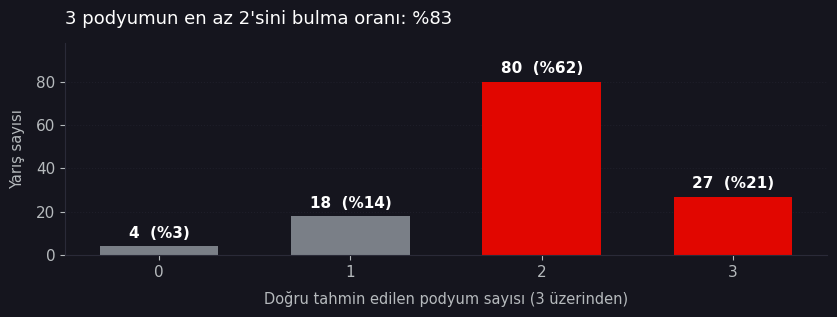

model_podyum
0     4
1    18
2    80
3    27
Toplam 129 yaris
En az 2 dogru: 107/129 = %82.9
Genel podyum isabeti: %66.9


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Yaris basina isabet dagilimi — dashboard gorseli (kendi kendine yeten)
import matplotlib.pyplot as plt

BG      = "#15151E"
CIZGI   = "#2A2A38"
BEYAZ   = "#FFFFFF"
GRI     = "#B6BABD"
SOLUK   = "#7A7F87"
KIRMIZI = "#E10600"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": BEYAZ, "axes.labelcolor": GRI,
    "xtick.color": GRI, "ytick.color": GRI,
    "axes.edgecolor": CIZGI, "grid.color": CIZGI,
    "font.family": "DejaVu Sans", "font.size": 11,
})

dagilim = (sonuc["model_podyum"]
           .value_counts().reindex([0, 1, 2, 3], fill_value=0).sort_index())
toplam = int(dagilim.sum())


fig, ax = plt.subplots(figsize=(8.5, 3.3))          # kutu 395x154 orani
renkler = [SOLUK, SOLUK, KIRMIZI, KIRMIZI]          # 2 ve 3 vurgulu
cubuk = ax.bar([str(i) for i in dagilim.index], dagilim.values,
               color=renkler, width=0.62)

for c, v in zip(cubuk, dagilim.values):
    ax.text(c.get_x() + c.get_width()/2, v + toplam*0.02,
            f"{v}  (%{v/toplam*100:.0f})", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=BEYAZ)

ax.set_xlabel("Doğru tahmin edilen podyum sayısı (3 üzerinden)",
              fontsize=10.5, labelpad=8)
ax.set_ylabel("Yarış sayısı", fontsize=10.5, labelpad=8)
en_az_2 = int(dagilim.loc[2] + dagilim.loc[3])
oran_en_az_2 = en_az_2 / toplam * 100
oran_genel = (dagilim.index.to_numpy() * dagilim.values).sum() / (toplam * 3) * 100

ax.set_title(f"3 podyumun en az 2'sini bulma oranı: %{oran_en_az_2:.0f}",
             fontsize=13, color=BEYAZ, pad=14, loc="left")
ax.set_ylim(0, dagilim.max() * 1.22)
ax.yaxis.grid(True, linestyle=":", alpha=0.45)
ax.set_axisbelow(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["bottom", "left"]:
    ax.spines[s].set_color(CIZGI)

plt.tight_layout()
plt.savefig("dash_dagilim.png", dpi=200, facecolor=BG)
plt.show()

print(dagilim.to_string())
print(f"Toplam {toplam} yaris")
print(f"En az 2 dogru: {en_az_2}/{toplam} = %{oran_en_az_2:.1f}")
print(f"Genel podyum isabeti: %{oran_genel:.1f}")
from google.colab import files
files.download("dash_dagilim.png")

## 9 · Özet

**Problem.** Yarış öncesi bilgiyle her yarışta kimin podyuma çıkacağını tahmin etmek.
İkili sınıflandırma → lojistik regresyon.

**Rakip.** Projenin baseline kuralı: *grid ≤ 3 ise podyum.* Test setinde F1 %67,1.

### Ne oldu

| Sonuç | Değer |
|---|---|
| Model, varsayılan 0,5 eşiğinde | F1 %62,4 — baseline'ın **altında** |
| Model, eşik 0,40'ta | F1 %67,3 — baseline'ı **0,2 puan** geçiyor |
| Zengin özellikler (hava + pist, 47 sütun) | Katkı **yok**, hatta hafif zarar |
| Rastgele bölme | Skoru şişirmiyor ama soruyu yanlış soruyor |

### Yarış bazında

129 test yarışında model ile baseline birbirine çok yakın:

- **Kazanan tahmini:** model %50,4 · baseline %50,4 — **eşit**
- **Podyum isabeti:** model 2,01/3 · baseline 2,02/3 — baseline **çok az önde**
- Model 129 yarışın 107'sinde (%82,9) üç podyumdan en az ikisini doğru buluyor

### Ne öğrendik

Model, tek satırlık bir sezgisel kuralı anlamlı şekilde geçemiyor. Bu, projenin ana
tezini doğruluyor: **yarış sonucunu büyük ölçüde başlangıç pozisyonu belirliyor** ve
grid'in taşıdığı bilginin üstüne koyacak çok şey yok.

Modelin baseline'a göre tek gerçek avantajı, sabit bir kural yerine **olasılık**
üretmesi. Bölüm 8'deki örneklerde bu görünüyor: model sadece "kim podyum yapar"
demiyor, her sürücüye bir yüzde veriyor ve o yüzdeye göre sıralıyor.

### Bilinen kusur

Karar eşiği test setine bakılarak seçildi. Doğrusu ayrı bir doğrulama seti kullanmak;
bu iterasyonda basitlik için iki parçalı bölme tercih edildi, dolayısıyla raporlanan
F1 bir miktar iyimser.

In [ ]:
yaris_goster(2024, 24)


=== Abu Dhabi Grand Prix 2024 (tur 24) ===

     driver_name  grid_position  olasilik tahmini_podyum gercek_podyum
    Lando Norris              1      78.4              ✓             ✓
    Carlos Sainz              3      53.5              ✓             ✓
   Oscar Piastri              2      53.1              ✓              
  Max Verstappen              4      43.3                             
  George Russell              6      33.9                             
    Pierre Gasly              5      10.5                             
 Nico Hülkenberg              7       6.4                             
 Fernando Alonso              8       4.5                             
    Sergio Pérez             10       4.5                             
 Valtteri Bottas              9       2.7                             
    Yuki Tsunoda             11       2.2                             
  Lewis Hamilton             16       1.7                             
 Charles Leclerc             19 